# Eutelsat OneWeb Flyovers at REACH Site:

This notebook produces the experimental results used for identifying and visualising Eutelsat OneWeb satellite flyovers at the Radio Experiment for the Analysis of Cosmic Hydrogen (REACH) site in the Karoo radio reserve, South Africa. 

### Initialising Satellite Data:

Satellite Two-Line Elements (TLEs) are first loaded and filtered to identify the OneWeb satellites relevant within the observation window. Satellite trajectories are propagated using the specified observation durection and temporal resolution, while accounting for the REACH site coordinates and horizon profile.

In [1]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Time Array:
ts = load.timescale()
length = 3600*1.5 # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London",51.5,0.128], ["REACH",-30.7,-21.5]]

In [3]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=10,
    obs_lat=-30.71131,
    obs_lon=21.4476236,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="oneweb"
)

Processing satellites: 100%|██████████| 654/654 [01:57<00:00,  5.56satellite/s]


In [4]:
n_flyovers = len(data)
norads = []
for flyover in data:
    tle_2 = flyover['TLE'][1].split(" ")  # get NORAD from TLE line 2
    norads.append(tle_2[1])  # append NORADs

print(f"Number of OneWeb Flyovers at REACH Site: {len(data)}")
print(f"List of NORADS: {', '.join(norads)}.")

Number of OneWeb Flyovers at REACH Site: 44
List of NORADS: 49288, 49291, 49295, 49297, 49302, 49306, 49314, 51645, 54113, 54114, 54115, 54116, 54117, 54118, 54120, 54121, 54122, 54123, 54124, 54125, 54126, 54130, 54134, 54135, 54136, 54138, 54140, 54143, 54144, 54145, 54147, 55803, 55805, 55806, 55810, 55812, 55813, 55818, 55819, 55830, 55832, 55834, 55835, 56725.


### Plotting 3-D Trajectories of OneWeb Flyovers:

The computed satellite trajectories are visualised in three dimensions (3-D) relative to Earth and the REACH site. This provides an overview as to how predicted flyovers can be examined, and how interfaces like `widget` can also be incorporated to interact with this 3-D visualisation.

In [5]:
%matplotlib widget

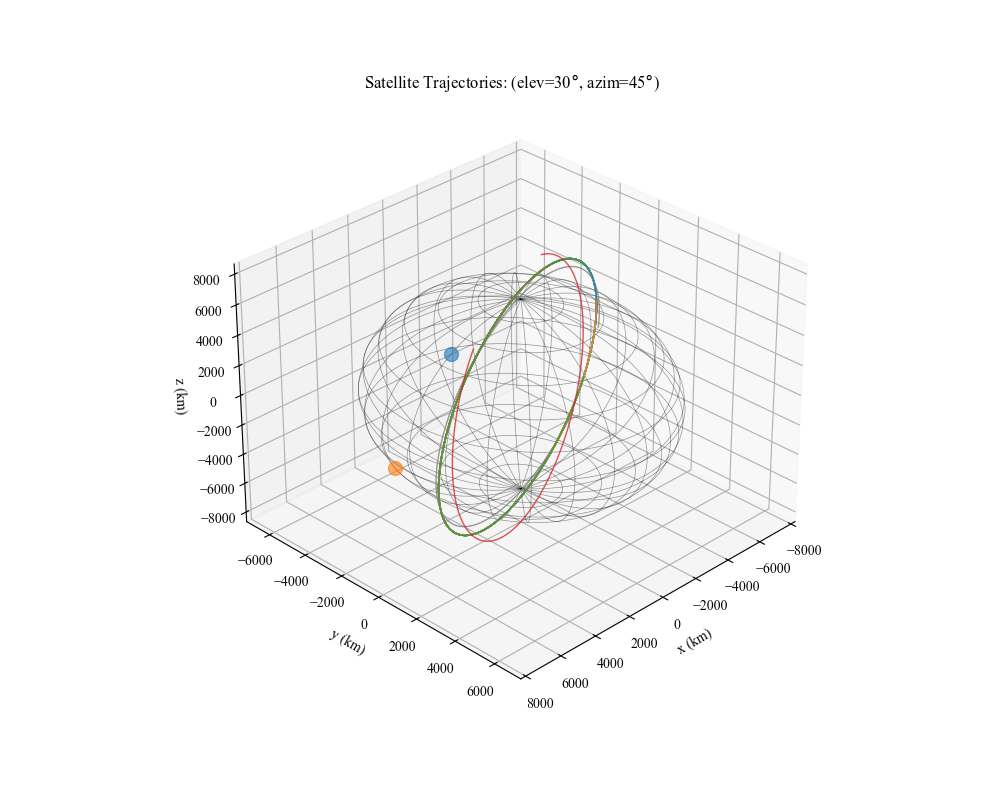

In [7]:
from astrotrack.satcon_properties import plot_satellite_trajectory

plot_satellite_trajectory(
    data,
    elev=30,
    azim=45,
    time=epochs_of_orbit,
    ref_points=ref_locations,
    show_legend=False,
    figsize=(10, 8),
    font_family="Times New Roman"
)